### Built a basic chatbot with Langgraph (GRAPH API)


In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
  

In [2]:
# creating a state that is actually a shared memory by all the nodes 
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]
  

In [3]:
import os
from dotenv import load_dotenv,find_dotenv
load_dotenv(find_dotenv())

True

In [4]:
#.chat_models import init_chat_model

# using chatgroq
#from langchain_groq import ChatGroq
#llm = ChatGroq(model="llma3-8b-8192")


#using init_chat_model
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",

)


In [5]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001CFF1F36CF0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CFF1F37770>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
# creating a node functionality

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:
graph_builder =StateGraph(State)

#adding node to the graph

graph_builder.add_node("LLmChatbot", chatbot)

# Adding edges

graph_builder.add_edge(START,"LLmChatbot")
graph_builder.add_edge("LLmChatbot",END)

#compile the graph
graph = graph_builder.compile()

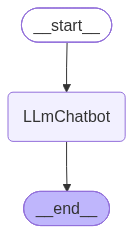

In [8]:
# visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
response = graph.invoke({"messages":"hi groq be bold and chill cold "})

In [10]:
response["messages"][-1].content

"**What's good?** I'm here to vibe with you, no stress. How's your day going so far?"

### ChatBot with Tool

In [12]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("what is genai?")

{'query': 'what is genai?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Generative_AI',
   'title': 'Generative AI',
   'content': 'Generative artificial intelligence (GenAI) is a subfield of artificial intelligence (AI) that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.',
   'score': 0.93086797,
   'raw_content': None,
   'id': '6c02d4-00'},
  {'url': 'https://www.snaplogic.com/glossary/what-is-genai',
   'title': 'What is Generative AI (GenAI)?',
   'content': 'ChatGPT Claude.AI\n\nTLDR: Generative AI (GenAI) is a type of artificial intelligence that learns from large amounts of data and then creates new content such as text, images, code, or music. It helps organizatio

In [17]:
# custom function 
def multiply(a:int,b:int)->int:
    """Multiply a and b

    args:
     a (int): first int 
     b (int): second int

    result:
     int: return output int

    """
    return a*b

In [18]:
tools = [tool,multiply]

In [21]:
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001CFF1F36CF0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CFF1F37770>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engin

In [20]:
llm_with_tools.invoke("multiply 7 ,9")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'zm348t48w', 'function': {'arguments': '{"a":7,"b":9}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1787, 'total_tokens': 1806, 'completion_time': 0.034562537, 'completion_tokens_details': None, 'prompt_time': 0.141414117, 'prompt_tokens_details': None, 'queue_time': 0.054683862, 'total_time': 0.175976654}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fdc37-a743-7ff2-abb7-c8c6e38ce621-0', tool_calls=[{'name': 'multiply', 'args': {'a': 7, 'b': 9}, 'id': 'zm348t48w', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1787, 'output_tokens': 19, 'total_tokens': 1806})

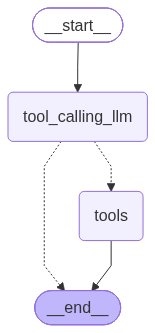

In [24]:
#Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


#graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#add edges 
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

# graph compile

graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

